# BigNeuron Benchmark — Evaluation

| Method | Description |
|--------|-------------|
| **ours** | Riemannian FMM tracer (per-Z soma detection) |
| **vaa3d** | Vaa3D APP2 algorithm |

**Metrics (via pyneval)**
- `ssd` — Spatial Structure Distance (낮을수록 좋음)
- `recall / precision / f1` — branch overlap

> gold standard SWC는 원본 픽셀 단위 → µm 변환 후 비교

In [1]:
from pathlib import Path
import re, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
import tifffile
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# 경로 설정
# ─────────────────────────────────────────────

# ROOT: benchmark/ 디렉토리 (이 노트북 기준 상위 폴더)
ROOT = Path('..').resolve()

# GOLD_DIR: gold standard SWC 및 pixelsize.txt 위치
#   - {stem}.swc          : 정답 뉴런 구조 (픽셀 좌표)
#   - {stem}.pixelsize.txt: voxel 크기 정보 (µm 변환에 사용)
GOLD_DIR = ROOT / 'data' / 'gold_standard'

# RESULTS_DIR: 각 method의 tracing 결과 SWC 위치
#   - results/ours/{stem}.swc   : 우리 tracer 결과 (µm 단위로 저장됨)
#   - results/vaa3d/{stem}.swc  : Vaa3D APP2 결과 (픽셀 단위로 저장됨)
RESULTS_DIR = ROOT / 'results'

# OUT_DIR: ours method 중간 산출물 위치 (MIP 시각화에서 preprocessed stack 로드용)
#   - {stem}/stack_preprocessed.tif : 전처리된 이미지 스택
#   - {stem}/preprocess_meta.npz    : voxel_iso 등 메타 정보
OUT_DIR = ROOT / 'methods' / 'ours' / 'output'

# ─────────────────────────────────────────────
# 평가 도구 설정
# ─────────────────────────────────────────────

# PYNEVAL: pyneval 실행 파일 경로
#   tracing conda 환경에 설치된 버전 사용
#   (base 환경 pyneval과 버전이 다를 수 있으므로 절대경로 지정)
PYNEVAL = '/opt/homebrew/Caskroom/miniforge/base/envs/tracing/bin/pyneval'

# ─────────────────────────────────────────────
# 시각화 설정
# ─────────────────────────────────────────────

# METHODS: 비교할 method 목록 (결과 SWC가 있는 경우에만 평가됨)
METHODS = ['ours', 'vaa3d']

# METHOD_COLORS: MIP 오버레이 및 그래프에서 각 method에 사용할 색상
METHOD_COLORS = {'ours': '#4c9be8', 'vaa3d': '#e87b4c', 'gold': '#f5c518'}

# ─────────────────────────────────────────────
# 샘플 자동 수집
# ─────────────────────────────────────────────

# samples: ours 결과 SWC와 gold standard SWC가 모두 존재하는 stem만 수집
#   새 샘플 추가 시 results/ours/ 와 data/gold_standard/ 양쪽에 파일이 있어야 자동 포함됨
samples = sorted(set(
    p.stem for p in (RESULTS_DIR / 'ours').glob('*.swc')
) & set(
    p.stem for p in GOLD_DIR.glob('*.swc')
))
print(f'샘플: {samples}')

샘플: ['1201_01_s10mm_ch2.tif']


## Helper functions

In [2]:
def gold_voxel(stem):
    """pixelsize.txt에서 (voxel_xy, voxel_z) 읽기 (µm)"""
    txt = (GOLD_DIR / f'{stem}.pixelsize.txt').read_text()
    m = re.search(r'Voxel size:\s*([\d.]+)x[\d.]+x([\d.]+)', txt, re.I)
    return float(m.group(1)), float(m.group(2))


def gold_to_um_file(stem):
    """gold standard SWC 픽셀 좌표 → µm 변환, 임시 파일 반환"""
    vxy, vz = gold_voxel(stem)
    lines = []
    for line in (GOLD_DIR / f'{stem}.swc').read_text().splitlines():
        if line.startswith('#') or not line.strip():
            lines.append(line); continue
        p = line.split()
        p[2] = f'{float(p[2])*vxy:.4f}'
        p[3] = f'{float(p[3])*vxy:.4f}'
        p[4] = f'{float(p[4])*vz:.4f}'
        lines.append(' '.join(p))
    tmp = Path(f'/tmp/{stem}_gold_um.swc')
    tmp.write_text('\n'.join(lines))
    return tmp


def test_to_um_file(method, stem):
    """method SWC를 µm 단위로 변환한 경로 반환.
    ours  : 이미 µm → 원본 경로 그대로.
    vaa3d : 원본 픽셀 좌표 → gold 와 같은 voxel 크기로 µm 변환.
    """
    src = RESULTS_DIR / method / f'{stem}.swc'
    if method == 'ours':
        return src
    vxy, vz = gold_voxel(stem)
    lines = []
    for line in src.read_text().splitlines():
        if line.startswith('#') or not line.strip():
            lines.append(line); continue
        p = line.split()
        p[2] = f'{float(p[2])*vxy:.4f}'
        p[3] = f'{float(p[3])*vxy:.4f}'
        p[4] = f'{float(p[4])*vz:.4f}'
        lines.append(' '.join(p))
    tmp = Path(f'/tmp/{stem}_{method}_um.swc')
    tmp.write_text('\n'.join(lines))
    return tmp


def _run_pyneval(test_um_swc, gold_um_swc, metric):
    """pyneval 단일 메트릭 실행 → dict"""
    r = subprocess.run(
        [PYNEVAL, '--test', str(test_um_swc), '--gold', str(gold_um_swc), '--metric', metric],
        capture_output=True, text=True)
    out = {}
    for line in r.stdout.splitlines():
        if '=' in line:
            k, _, v = line.partition('=')
            try: out[k.strip()] = float(v.strip())
            except: pass
    return out


def pyneval_score(test_um_swc, gold_um_swc):
    """ssd / length 두 메트릭 실행 → 합쳐서 반환"""
    scores = {}
    scores.update(_run_pyneval(test_um_swc, gold_um_swc, 'ssd'))
    try:
        lm = _run_pyneval(test_um_swc, gold_um_swc, 'length')
        scores['length_recall']    = lm.get('recall',   float('nan'))
        scores['length_precision'] = lm.get('precision', float('nan'))
        scores['length_f1']        = lm.get('f1_score',  float('nan'))
    except Exception:
        pass
    return scores


def load_swc_segments(swc_path, scale_xy=1.0, scale_z=1.0):
    """SWC 읽어서 세그먼트 목록 반환.
    scale_xy, scale_z: 픽셀→µm 변환 (gold/vaa3d용). ours는 1.0.
    """
    nodes = {}
    for line in Path(swc_path).read_text().splitlines():
        if line.startswith('#') or not line.strip(): continue
        p = line.split()
        if len(p) < 7: continue
        nodes[int(p[0])] = (float(p[2])*scale_xy,
                             float(p[3])*scale_xy,
                             float(p[4])*scale_z,
                             int(p[6]))
    segs = []
    for nid, (x, y, z, pid) in nodes.items():
        if pid == -1 or pid not in nodes: continue
        px, py, pz, _ = nodes[pid]
        segs.append(((x, y, z), (px, py, pz)))
    return segs

## 정량 지표 계산

In [3]:
rows = []
for stem in samples:
    gold_um = gold_to_um_file(stem)
    for method in METHODS:
        test = RESULTS_DIR / method / f'{stem}.swc'
        if not test.exists(): continue
        test_um = test_to_um_file(method, stem)
        scores = pyneval_score(test_um, gold_um)
        rows.append({
            'sample': stem, 'method': method,
            'ssd':              scores.get('ssd_score',        float('nan')),
            'recall':           scores.get('recall',           float('nan')),
            'precision':        scores.get('precision',        float('nan')),
            'f1':               scores.get('f1_score',         float('nan')),
            'len_recall':       scores.get('length_recall',    float('nan')),
            'len_precision':    scores.get('length_precision', float('nan')),
            'len_f1':           scores.get('length_f1',        float('nan')),
        })
        print(f"{method:8s}  {stem}"
              f"  ssd={scores.get('ssd_score', float('nan')):.2f}"
              f"  f1={scores.get('f1_score', float('nan')):.3f}"
              f"  len_f1={scores.get('length_f1', float('nan')):.3f}")

df = pd.DataFrame(rows)
df.to_csv('results_raw.csv', index=False)
df

ours      1201_01_s10mm_ch2.tif  ssd=14.73  f1=0.435  len_f1=0.327
vaa3d     1201_01_s10mm_ch2.tif  ssd=19.51  f1=0.392  len_f1=0.298


,sample,method,ssd,recall,precision,f1,len_recall,len_precision,len_f1
0,1201_01_s10mm_ch2.tif,ours,14.726334,0.359581,0.551271,0.435255,0.303866,0.354962,0.327433
1,1201_01_s10mm_ch2.tif,vaa3d,19.506121,0.720966,0.269100,0.391918,0.560616,0.203191,0.298275


## 요약 테이블

In [4]:
METRICS_SSD = ['ssd', 'recall', 'precision', 'f1']
METRICS_LEN = ['len_recall', 'len_precision', 'len_f1']
ALL_METRICS = METRICS_SSD + METRICS_LEN

summary = df.groupby('method')[ALL_METRICS].mean().round(4)
summary.style \
    .highlight_min(subset=['ssd'], color='lightgreen') \
    .highlight_max(subset=[m for m in ALL_METRICS if m != 'ssd'], color='lightgreen')

,ssd,recall,precision,f1,len_recall,len_precision,len_f1
method,,,,,,,
ours,14.726300,0.359600,0.551300,0.435300,0.303900,0.355000,0.327400
vaa3d,19.506100,0.721000,0.269100,0.391900,0.560600,0.203200,0.298300


## 지표 비교 그래프

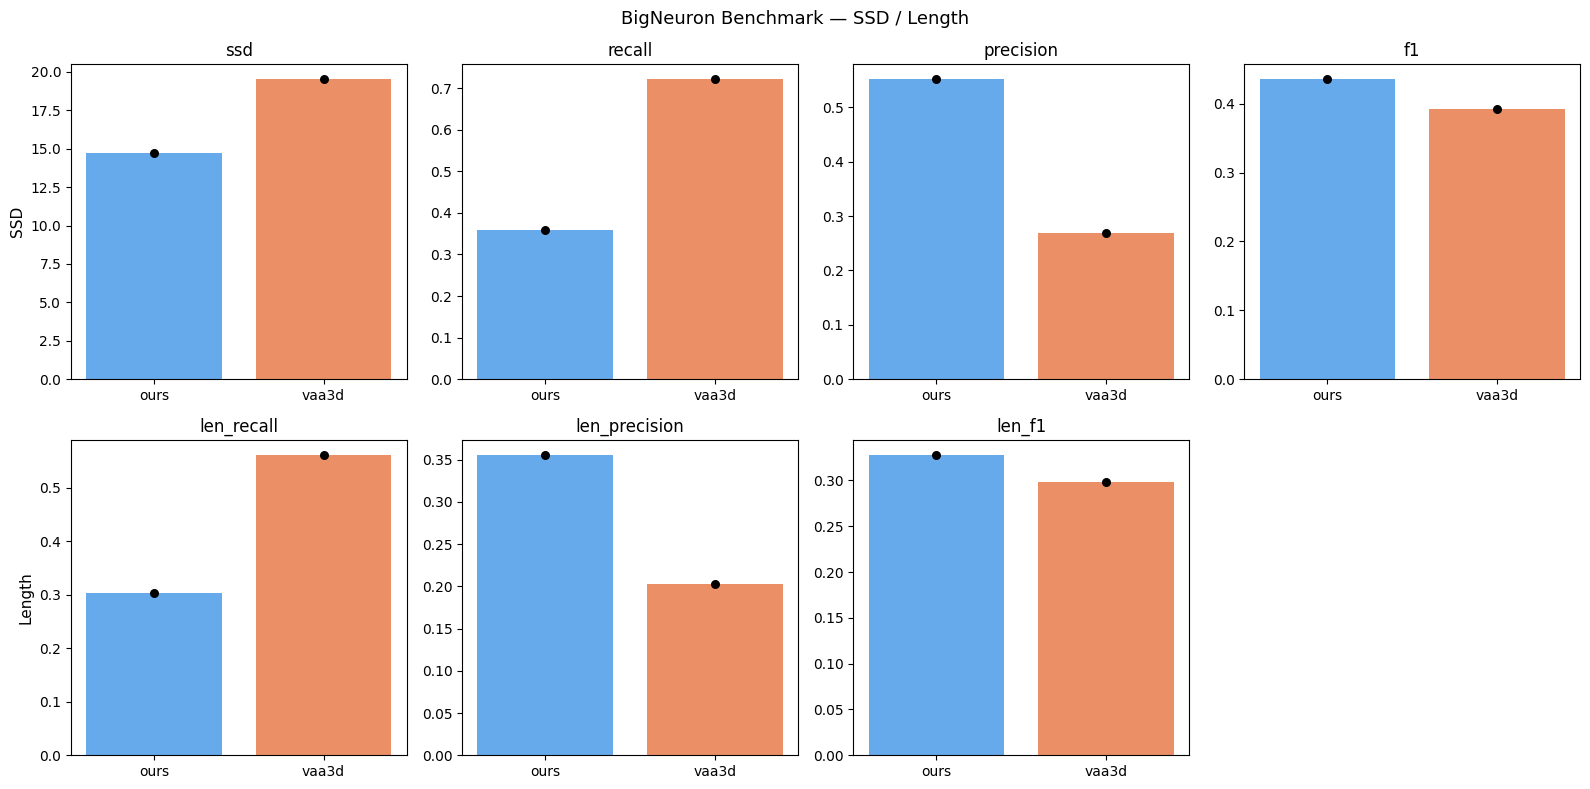

In [5]:
plot_groups = [
    ('SSD',    ['ssd', 'recall', 'precision', 'f1']),
    ('Length', ['len_recall', 'len_precision', 'len_f1']),
]

n_cols = max(len(g[1]) for g in plot_groups)
n_rows = len(plot_groups)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
palette = [METHOD_COLORS[m] for m in METHODS if m in METHOD_COLORS]

for row, (group_name, metrics) in enumerate(plot_groups):
    for col in range(n_cols):
        ax = axes[row, col]
        if col >= len(metrics):
            ax.axis('off'); continue
        metric = metrics[col]
        vals = [df[df.method == m][metric].values for m in METHODS]
        bars = ax.bar(METHODS, [float(np.nanmean(v)) for v in vals], color=palette, alpha=0.85)
        for bar, vs in zip(bars, vals):
            for v in vs:
                if not np.isnan(float(v)):
                    ax.scatter(bar.get_x() + bar.get_width()/2, float(v),
                               color='black', s=30, zorder=5)
        ax.set_title(metric)
        ax.set_ylim(0, None)
        if col == 0:
            ax.set_ylabel(group_name, fontsize=11)

plt.suptitle('BigNeuron Benchmark — SSD / Length', fontsize=13)
plt.tight_layout()
plt.savefig('benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()

## MIP 오버레이 시각화

각 샘플에 대해 XY / XZ / YZ 3방향 MIP 위에 SWC를 겹쳐 표시합니다.
- **이미지**: 전처리된 스택 (stack_preprocessed.tif)
- **Gold standard**: 노란색
- **Ours**: 파란색
- **Vaa3D**: 주황색

In [6]:
def segs_to_lc_xy(segs, voxel, color, lw=0.7, alpha=0.9):
    lines = [[(x1/voxel, y1/voxel), (x2/voxel, y2/voxel)]
             for (x1,y1,z1),(x2,y2,z2) in segs]
    return LineCollection(lines, colors=color, linewidths=lw, alpha=alpha)

def segs_to_lc_xz(segs, voxel_xy, voxel_z, color, lw=0.7, alpha=0.9):
    lines = [[(x1/voxel_xy, z1/voxel_z), (x2/voxel_xy, z2/voxel_z)]
             for (x1,y1,z1),(x2,y2,z2) in segs]
    return LineCollection(lines, colors=color, linewidths=lw, alpha=alpha)

def segs_to_lc_yz(segs, voxel_xy, voxel_z, color, lw=0.7, alpha=0.9):
    lines = [[(y1/voxel_xy, z1/voxel_z), (y2/voxel_xy, z2/voxel_z)]
             for (x1,y1,z1),(x2,y2,z2) in segs]
    return LineCollection(lines, colors=color, linewidths=lw, alpha=alpha)


def mip_figure(stem, use_original=True):
    """
    use_original=False : preprocessed stack (stack_preprocessed.tif) 사용
    use_original=True  : 원본 이미지 (data/images/{stem}.tif) 사용
    """
    vxy, vz = gold_voxel(stem)

    if use_original:
        img_path = ROOT / 'data' / 'images' / f'{stem}.tif'
        # 원본 좌표계: Gold/Vaa3D는 픽셀 그대로, Ours는 µm→픽셀 변환
        # MIP 축 단위: 원본 픽셀
        px_xy, px_z = 1.0, 1.0       # 이미지 표시용 voxel (픽셀 단위)
        swc_info = [
            ('Gold',  GOLD_DIR / f'{stem}.swc',              METHOD_COLORS['gold'],  1.0, 1.0),
            ('Ours',  RESULTS_DIR / 'ours' / f'{stem}.swc',  METHOD_COLORS['ours'],  1/vxy, 1/vz),  # µm→px
            ('Vaa3D', RESULTS_DIR / 'vaa3d'/ f'{stem}.swc',  METHOD_COLORS['vaa3d'], 1.0, 1.0),
        ]
        title_suffix = 'original image'
    else:
        img_path = OUT_DIR / stem / 'stack_preprocessed.tif'
        meta = np.load(str(OUT_DIR / stem / 'preprocess_meta.npz'))
        voxel_iso = float(meta['voxel_iso'])
        # preprocessed 좌표계: Ours는 µm 그대로, Gold/Vaa3D는 픽셀→µm 변환
        px_xy, px_z = voxel_iso, voxel_iso
        swc_info = [
            ('Gold',  GOLD_DIR / f'{stem}.swc',              METHOD_COLORS['gold'],  vxy, vz),
            ('Ours',  RESULTS_DIR / 'ours' / f'{stem}.swc',  METHOD_COLORS['ours'],  1.0, 1.0),
            ('Vaa3D', RESULTS_DIR / 'vaa3d'/ f'{stem}.swc',  METHOD_COLORS['vaa3d'], vxy, vz),
        ]
        title_suffix = 'preprocessed'

    if not img_path.exists():
        print(f'{stem}: {img_path.name} 없음'); return

    print(f'Loading {img_path.name} ...')
    stack = tifffile.imread(str(img_path)).astype(np.float32)
    mip_xy = stack.max(axis=0)
    mip_xz = stack.max(axis=1)
    mip_yz = stack.max(axis=2)

    swc_segs = []
    for label, path, color, sxy, sz in swc_info:
        if not path.exists():
            swc_segs.append((label, None, color)); continue
        segs = load_swc_segments(path, scale_xy=sxy, scale_z=sz)
        swc_segs.append((label, segs, color))

    nrows = 1 + len(swc_segs)
    fig, axes = plt.subplots(nrows, 3, figsize=(15, 4*nrows))
    proj_titles = ['XY (Z-MIP)', 'XZ (Y-MIP)', 'YZ (X-MIP)']
    mips = [mip_xy, mip_xz, mip_yz]

    for col, (mip, title) in enumerate(zip(mips, proj_titles)):
        ax = axes[0, col]
        vmax = np.percentile(mip[mip>0], 99) if mip.max() > 0 else 1
        ax.imshow(mip, cmap='gray', origin='upper',
                  aspect='auto' if col > 0 else 'equal', vmax=vmax)
        ax.set_title(title, fontsize=11)
        if col == 0: ax.set_ylabel('Image', fontsize=11)
        ax.axis('off')

    for row, (label, segs, color) in enumerate(swc_segs, start=1):
        for col, mip in enumerate(mips):
            ax = axes[row, col]
            vmax = np.percentile(mip[mip>0], 99) if mip.max() > 0 else 1
            ax.imshow(mip, cmap='gray', origin='upper',
                      aspect='auto' if col > 0 else 'equal', vmax=vmax)
            if segs:
                if col == 0:
                    ax.add_collection(segs_to_lc_xy(segs, px_xy, color))
                elif col == 1:
                    ax.add_collection(segs_to_lc_xz(segs, px_xy, px_z, color))
                else:
                    ax.add_collection(segs_to_lc_yz(segs, px_xy, px_z, color))
            if col == 0: ax.set_ylabel(label, fontsize=11, color=color)
            ax.axis('off')

    plt.suptitle(f'{stem}  [{title_suffix}]  —  Gold(노란) / Ours(파란) / Vaa3D(주황)',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    fname = f'mip_{stem}_{"orig" if use_original else "prep"}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

Loading 1201_01_s10mm_ch2.tif.tif ...


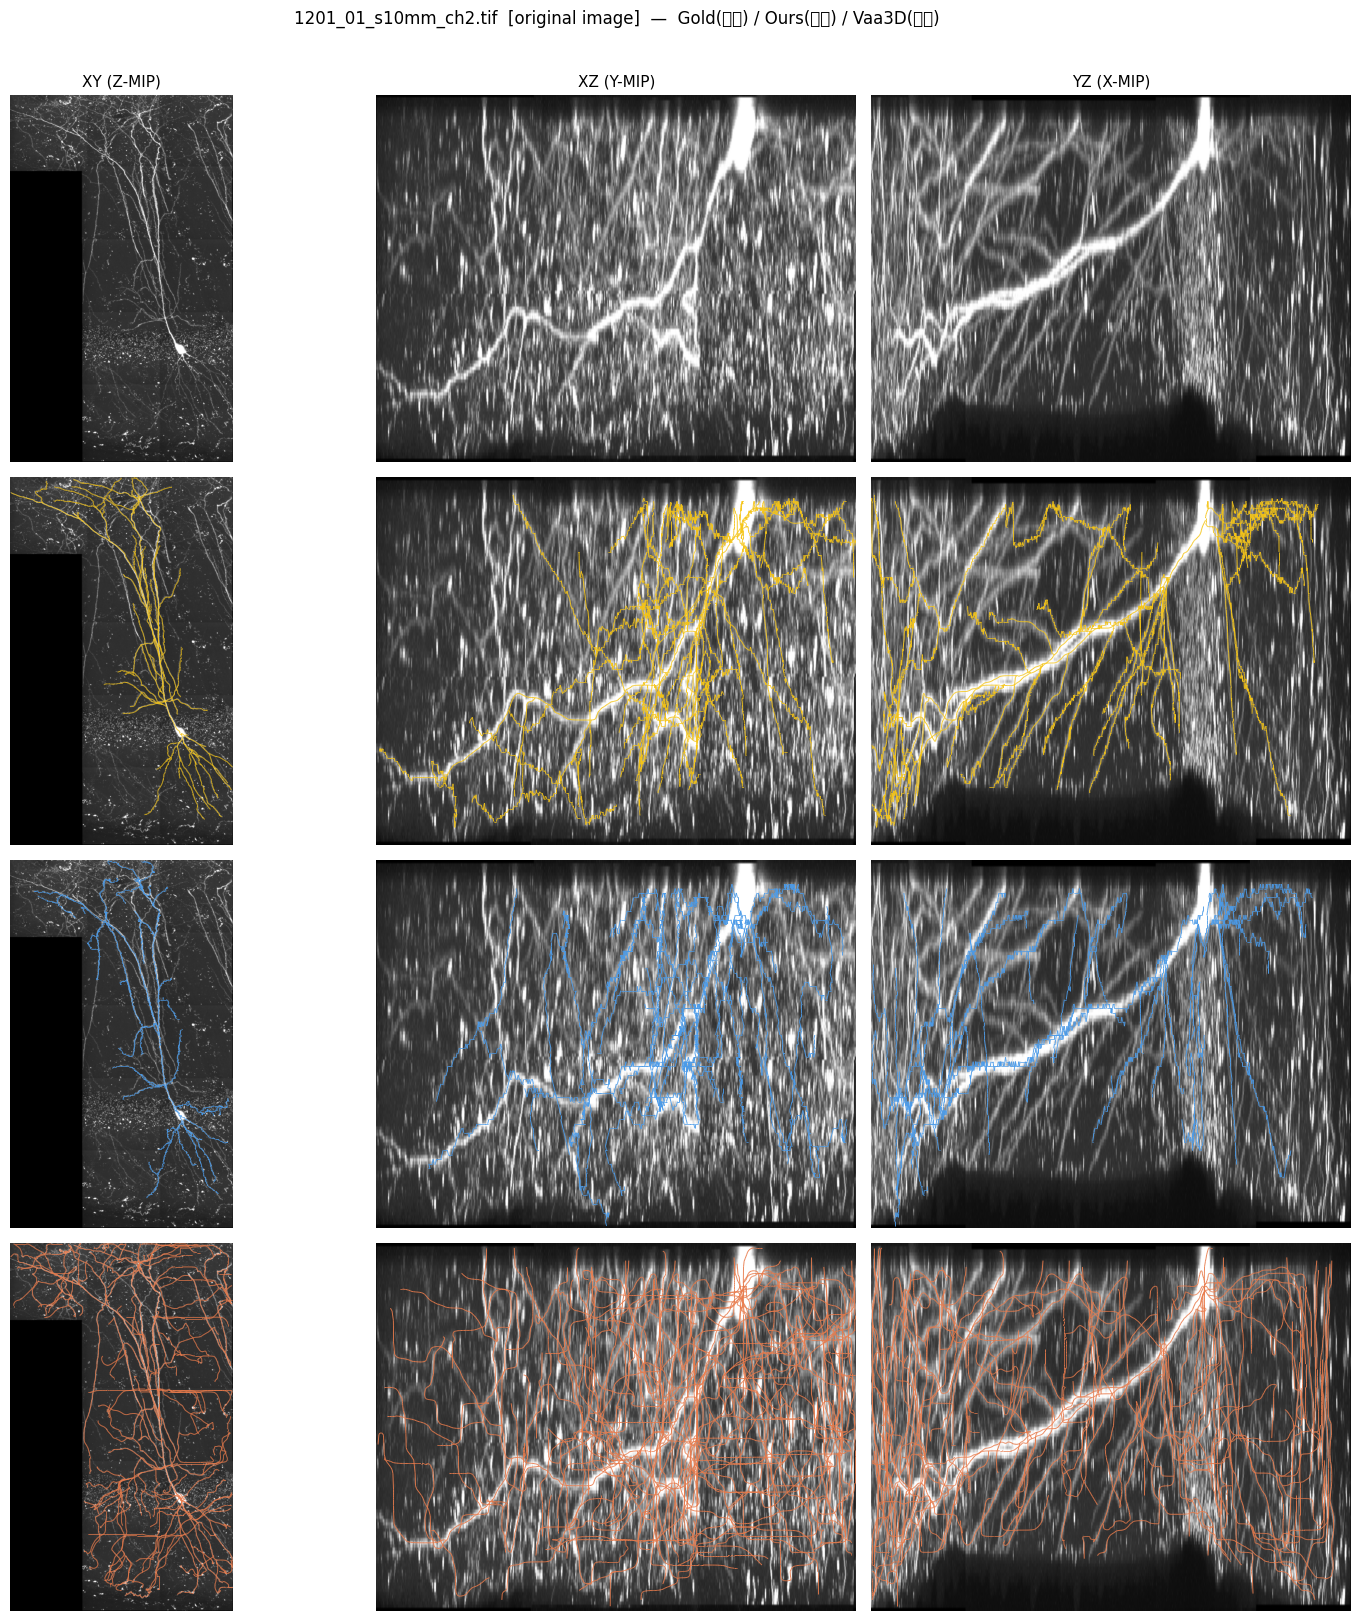

Saved: mip_1201_01_s10mm_ch2.tif_orig.png


In [7]:
for stem in samples:
#    mip_figure(stem, use_original=False)  # preprocessed
    mip_figure(stem, use_original=True)   # 원본